In [1]:
rm(list = ls())
gc()


setwd("/mnt/data00/minghui/project_NMF/02_NMFAllTissue/")
library(Seurat)
library(dplyr)
library(cowplot)
library(harmony)
library(readr) 
library(tidyr)
library(gplots)
library(reshape2)
suppressPackageStartupMessages(library(NMF))

library(AnnotationDbi)
library(org.Hs.eg.db)

library(paletteer)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,652502,34.9,1445940,77.3,1087282,58.1
Vcells,1213119,9.3,8388608,64.0,1924993,14.7


Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp


Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Loading required package: stats4

Loading required package: IRanges

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:NMF’:

    nrun


The following object is masked from ‘package:gplots’:

    space


The following object is masked from ‘package:tidyr’:

    expand


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    e

In [2]:
source('/mnt/data00/minghui/Fuctions/Markers_kno.R')
source('/mnt/data00/minghui/Fuctions/seurat_functions.R')

Error in library(MSigDB) : there is no package called ‘MSigDB’
Error in library(biomaRt) : there is no package called ‘biomaRt’
Error in library(visNetwork) : there is no package called ‘visNetwork’
Error in library(rjags) : there is no package called ‘rjags’
Error in library(infercnv) : there is no package called ‘infercnv’
Error in library(mHG) : there is no package called ‘mHG’
Error in library(VennDiagram) : there is no package called ‘VennDiagram’
Error in library(tsne) : there is no package called ‘tsne’
Error in library(nichenetr) : there is no package called ‘nichenetr’
Error in library(DiagrammeR) : there is no package called ‘DiagrammeR’
Error in library(SeuratWrappers) : 
  there is no package called ‘SeuratWrappers’
Error in library(nnls) : there is no package called ‘nnls’
Error in library(colormap) : there is no package called ‘colormap’
Error in library(genesorteR) : there is no package called ‘genesorteR’
Error in library(survminer) : there is no package called ‘survmin

In [3]:
cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

In [4]:
SC_Columnar <- readRDS(file = '/mnt/data00/minghui/project-trans_mut/00_raw_data/SC_Columnar_cells.rds')

# Data Preprocessing

In [4]:
SC_Columnar

dim(SC_Columnar)
# 33145  79522

An object of class Seurat 
33145 features across 79522 samples within 1 assay 
Active assay: RNA (33145 features, 0 variable features)
 7 dimensional reductions calculated: umap_MinDist_0.01_N_Neighbors_15, umap_MinDist_0.05_N_Neighbors_15, umap_MinDist_0.1_N_Neighbors_15, umap_MinDist_0.2_N_Neighbors_15, umap_MinDist_0.3_N_Neighbors_15, umap_MinDist_0.4_N_Neighbors_15, umap_MinDist_0.5_N_Neighbors_15

[1] 33145 79522

In [5]:
sample_name <- substr(rownames(SC_Columnar@meta.data), 1, nchar(rownames(SC_Columnar@meta.data)) - 19) 

length(unique(sample_name))
# [1] 14
SC_Columnar@meta.data$sample_name <- as.factor(sample_name)

names(sample_name) <-colnames(SC_Columnar)

SC_Columnar <- AddMetaData(object = SC_Columnar, metadata = sample_name, col.name = "sample_name")

[1] 74

In [25]:
table(SC_Columnar$tissue)


                  rectum                    colon          body of stomach 
                    3150                     4220                    41003 
       cardia of stomach                 duodenum                    ileum 
                   12032                     3199                     6737 
esophagogastric junction          lower esophagus 
                    2603                     6578 

In [ ]:
all.genes <- rownames(SC_Columnar)

SC_Columnar <- NormalizeData(SC_Columnar) %>% FindVariableFeatures( nfeatures = 3000,assay = 'RNA', selection.method = "vst") %>% 
ScaleData(features = all.genes) 

SC_Columnar <- RunPCA( SC_Columnar,npcs = 30)

## Remove Batch Effects

In [8]:
DefaultAssay(SC_Columnar)

[1] "RNA"

In [ ]:
SC_Columnar <-RunHarmony(SC_Columnar, reduction.use = 'pca',lambda = 1,group.by.vars = 'sample_name')

SC_Columnar <- FindNeighbors(SC_Columnar, reduction = 'harmony',dims = 1:20,)%>%
 FindClusters( reduction = 'harmony', resolution = 0.5) %>% 
RunUMAP(reduction = 'harmony',dims = 1:20)

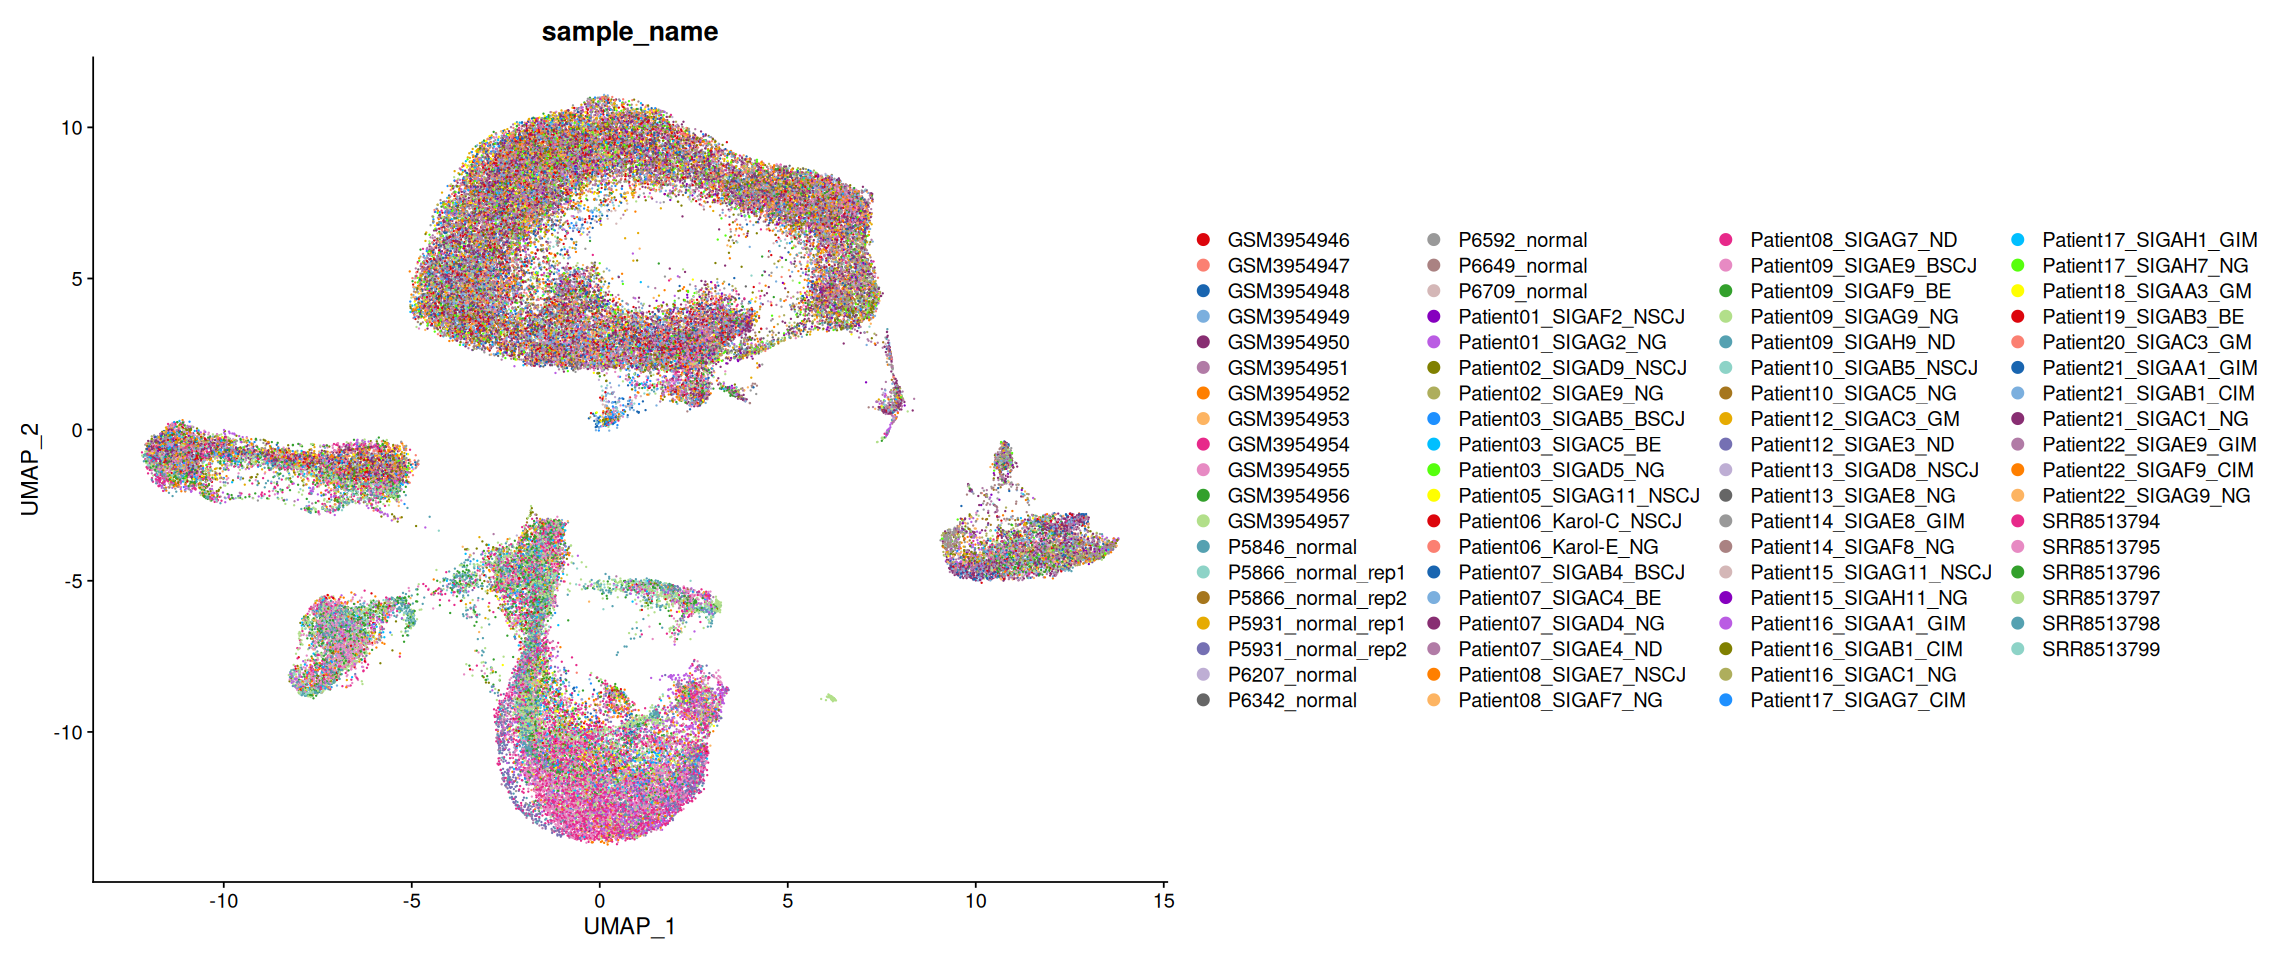

In [22]:

options(repr.plot.width =19, repr.plot.height=8)

DimPlot(SC_Columnar, reduction = "umap",label = F,group.by ='sample_name' ,cols = rep(cluster_cols,3))

In [33]:
sample_info <- table(SC_Columnar$sample_name,SC_Columnar$tissue) %>% as.data.frame() %>% subset(Freq !=0)
colnames(sample_info) <- c('Sample','Tissue','Cell')
head(sample_info)

saveRDS(sample_info ,'./01_sample_info.rds')

,Sample,Tissue,Cell
,<fct>,<fct>,<int>
73,SRR8513798,rectum,2331
74,SRR8513799,rectum,819
145,SRR8513796,colon,1479
146,SRR8513797,colon,2741
149,GSM3954946,body of stomach,2518
150,GSM3954947,body of stomach,1768


In [14]:
SC_Columnar

An object of class Seurat 
33145 features across 79522 samples within 1 assay 
Active assay: RNA (33145 features, 3000 variable features)
 10 dimensional reductions calculated: umap_MinDist_0.01_N_Neighbors_15, umap_MinDist_0.05_N_Neighbors_15, umap_MinDist_0.1_N_Neighbors_15, umap_MinDist_0.2_N_Neighbors_15, umap_MinDist_0.3_N_Neighbors_15, umap_MinDist_0.4_N_Neighbors_15, umap_MinDist_0.5_N_Neighbors_15, pca, harmony, umap

##  ID Transform

In [ ]:
ids=select(org.Hs.eg.db,keys = rownames(SC_Columnar),
           columns = c('ENSEMBL','SYMBOL'),
           keytype = 'ENSEMBL')

ids=na.omit(ids)

length(unique(ids$SYMBOL))

ids=ids[!duplicated(ddids$SYMBOL),]

ids=ids[!duplicated(ids$ENSEMBL),]

In [38]:
RenameGenesSeurat <- function(obj,newnames,gene.use=NULL,de.assay="Spatial") {
  lassays <- Assays(obj)
  #names(obj@assays)
  assay.use <- obj@reductions$pca@assay.used
  DefaultAssay(obj) <- de.assay
  if (is.null(gene.use)) {
    all_genenames <- rownames(obj)
  }else{
    all_genenames <- gene.use
    obj <- subset(obj,features=gene.use)
  }
  
  order_name <- function(v1,v2,ref){
    v2 <- make.names(v2,unique=T)
    df1 <- data.frame(v1,v2)
    rownames(df1) <- df1$v1
    df1 <- df1[ref,]
    return(df1)
  }
  
  df1 <- order_name(v1=all_genenames,v2=newnames,ref=rownames(obj))
  all_genenames <- df1$v1
  newnames <- df1$v2
  
  if ('SCT' %in% lassays) {
    if ('SCTModel.list' %in%  slotNames(obj@assays$SCT)) {
      obj@assays$SCT@SCTModel.list$model1@feature.attributes <- obj@assays$SCT@SCTModel.list$model1@feature.attributes[all_genenames,]
      rownames(obj@assays$SCT@SCTModel.list$model1@feature.attributes) <- newnames
    }
  }
  change_assay <- function(a1=de.assay,obj,newnames=NULL,all_genenames=NULL){
    RNA <- obj@assays[a1][[1]]
    if (nrow(RNA) == length(newnames)) {
      if (length(RNA@counts)) RNA@counts@Dimnames[[1]]            <- newnames
      if (length(RNA@data)) RNA@data@Dimnames[[1]]                <- newnames
      if (length(RNA@var.features)) {
        df1 <- order_name(v1=all_genenames,v2=newnames,ref=RNA@var.features)
        all_genenames1 <- df1$v1
        newnames1 <- df1$v2
        RNA@var.features            <- newnames1
      }
      if (length(RNA@scale.data)){
        df1 <- order_name(v1=all_genenames,v2=newnames,ref=rownames(RNA@scale.data))
        all_genenames1 <- df1$v1
        newnames1 <- df1$v2
        rownames(RNA@scale.data)    <- newnames1
      }
      
    } else {"Unequal gene sets: nrow(RNA) != nrow(newnames)"}
    obj@assays[a1][[1]] <- RNA
    return(obj)
  }
  
  for (a in lassays) {
    DefaultAssay(obj) <- a
    df1 <- order_name(v1=all_genenames,v2=newnames,ref=rownames(obj))
    all_genenames1 <- df1$v1
    newnames1 <- df1$v2
    obj <- change_assay(obj=obj,a1=a,newnames=newnames1,all_genenames=all_genenames1)
  }
  hvg <- VariableFeatures(obj,assay=assay.use)
  if (length(obj@reductions$pca)){
    df1 <- order_name(v1=all_genenames,v2=newnames,ref=hvg)
    df1 <- df1[rownames(obj@reductions$pca@feature.loadings),]
    all_genenames1 <- df1$v1
    newnames1 <- df1$v2
    rownames(obj@reductions$pca@feature.loadings) <- newnames1
  }
  try(obj[[de.assay]]@meta.features <- data.frame(row.names = rownames(obj[[de.assay]])))
  return(obj)
}

SC_Columnar <- RenameGenesSeurat(obj=SC_Columnar,de.assay = 'RNA',newnames=ids$SYMBOL,gene.use =ids$ENSEMBL )



[1] "Run this before integration. It only changes obj@assays$*@counts, @data and @scale.data, @var.features,@reductions$pca@feature.loadings"


In [41]:
saveRDS(SC_Columnar,'./01_SC_Columnar.rds')

In [40]:
SC_Columnar@assays$RNA@counts[1:4,1:4]

4 x 4 sparse Matrix of class "dgCMatrix"
        SRR8513799-CTCACACGTCACCCAG-1 SRR8513794-GTCGGGTCAATGACCT-1
FAM138A                             .                             .
OR4F5                               .                             .
OR4F29                              .                             .
OR4F16                              .                             .
        SRR8513798-GTGTTAGTCCTGCCAT-1 SRR8513794-TTTATGCCACGAAAGC-1
FAM138A                             .                             .
OR4F5                               .                             .
OR4F29                              .                             .
OR4F16                              .                             .

In [ ]:

SC_Columnar <- FindVariableFeatures(SC_Columnar, nfeatures = 3000,
                                     assay = 'RNA',
                                     selection.method = "vst") 

all.genes <- rownames(SC_Columnar)

# Scale the data, run PCA, find neighbors, find clusters, and run UMAP and t-SNE

SC_Columnar <- ScaleData(SC_Columnar ,features = all.genes,do.center = F)  %>% 
   RunPCA(npcs = 50,features = VariableFeatures(object = SC_Columnar)) %>% 
   FindNeighbors( dims = 1:30) %>% 
  FindNeighbors( reduction = 'pca',dims = 1:30) %>% 
  FindClusters( reduction = 'pca', resolution = 0.5) %>% 
RunUMAP( reduction = 'pca',dims = 1:30) %>% RunTSNE(reduction = 'pca',dims = 1:30)


In [5]:
SC_Columnar <-readRDS('./01_SC_Columnar.rds')

In [ ]:

Idents(SC_Columnar) <- 'sample_name'

split_list <- SplitObject(SC_Columnar,split.by = 'sample_name' )

In [13]:
saveRDS(split_list , file = './01_split_list.rds')

In [6]:
split_list <- readRDS('./01_split_list.rds')

In [ ]:
plot_list = list() 

# Iterate over each split object

for (i in names(split_list)) { 
  # Discard data with less than 150 columns
  if (ncol(split_list[[i]]) < 150) {
    next
  }
  
  split_list[[i]] = SCTransform(split_list[[i]], return.only.var.genes = FALSE) %>%
    RunPCA() %>%
    FindNeighbors() %>%
    FindClusters(resolution = 1)

  p = DotPlot(split_list[[i]], group.by = 'seurat_clusters', features = unique(Markers_kno), cluster.idents = T, col.min = 0) + coord_flip()
  
  plot_list[[i]] = p 
}  

pdf("./02_merge.list_plots.pdf") 
for (i in  1:length(plot_list)) { 
  print(plot_list[[i]]) 
} 
dev.off()


In [ ]:
path <- "./01_NMF_res/"

if (!dir.exists(path)) {
  dir.create(path)
}


range = 3:15
gmin = 3
ncores = 10

for( i in names(split_list)) {
  obj = SCTransform(split_list[[i]], return.only.var.genes = FALSE)
  
  data = GetAssayData(obj, slot = 'scale.data') %>% as.matrix()
  data = data[VariableFeatures(obj),]
  data[data < 0] = 0
  data = data[apply(data, 1, var) > 0, ]
  
  if (ncol(data) > 150) {
    res.list = parallel::mclapply(range, function(r){
      nmf(data, rank = r, nrun = 1, seed = 'ica', method = 'nsNMF')
    }, mc.cores = ncores)
    names(res.list) = range
    saveRDS(res.list,file = paste0(path,i ,"_res.list.rds"))
    print(i)
  }
} 

In [11]:
NMF_Sample_Patient <- c()

files <- list.files(path)

 NMF_Sample_Patient <- c()

 
for (file in files) {
  if (!grepl("_res.list.rds", file)) {
    next
  }

  NMF_Sample_Patient <- c(NMF_Sample_Patient, gsub("_res.list.rds", "", file))
}

NMF_Sample_Patient

saveRDS(NMF_Sample_Patient,file = './02_NMF_Sample_Patient.rds')


[1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  
[40] "Patient14_SIGAE8_GIM"  "Patient14_SIGAF8_NG"   "Patient15_SIGAH11_NG" 
[43] "Patient16_SIGAA1_GIM"  "Patient16_SIGAB1_CIM"  "Patient16_SIGAC1_NG"  
[46] "Patient17_SIGAG7_CIM"  "Patient17_SIGAH1_GIM"  "Patient17_SIGAH7_NG"  
[49] "Patient18_SIGAA3_GM"   "Patient19_SIGAB3_BE"   "Patient20_SIGAC3_GM"  
[52] "Patient21_SIGAA1_GIM"  "Patient21_SIGAB1_CIM"  "Patient21_SIGAC1_NG"  
[55] "Patient22_SIGAE9_GIM"  "Patient22_SIGAF9_CIM"  "Patient22_SIGAG9_NG"  
[58] "SRR8513794"            "SRR8513795"            "SRR8513796"           
[61] "SRR8513797"            "SRR8513798"            "SRR8513799"

In [10]:
length(NMF_Sample_Patient)
NMF_Sample_Patient

res.list_L<- list()

for(i in  NMF_Sample_Patient){
    a <- readRDS(paste0(path,i ,"_res.list.rds"))
    res.list_L[[i]] <- a
}

[1] 63

[1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  
[40] "Patient14_SIGAE8_GIM"  "Patient14_SIGAF8_NG"   "Patient15_SIGAH11_NG" 
[43] "Patient16_SIGAA1_GIM"  "Patient16_SIGAB1_CIM"  "Patient16_SIGAC1_NG"  
[46] "Patient17_SIGAG7_CIM"  "Patient17_SIGAH1_GIM"  "Patient17_SIGAH7_NG"  
[49] "Patient18_SIGAA3_GM"   "Patient19_SIGAB3_BE"   "Patient20_SIGAC3_GM"  
[52] "Patient21_SIGAA1_GIM"  "Patient21_SIGAB1_CIM"  "Patient21_SIGAC1_NG"  
[55] "Patient22_SIGAE9_GIM"  "Patient22_SIGAF9_CIM"  "Patient22_SIGAG9_NG"  
[58] "SRR8513794"            "SRR8513795"            "SRR8513796"           
[61] "SRR8513797"            "SRR8513798"            "SRR8513799"

In [11]:
names(res.list_L) <- NMF_Sample_Patient
     
modules_L <- list()
res_optima_L <- list()
coefs_L <- list()
scores_L <- list()
gmin = 3

In [12]:
for (i in NMF_Sample_Patient) { 
    if (!is.null(res.list_L[[i]])) {
        modules.list = lapply(res.list_L[[i]], function(x) if (!is.null(x)) NMFToModules(x, gmin = gmin) else NULL)
        
        modules.list = Filter(Negate(is.null), modules.list)
        
        print(sapply(modules.list, length))
        
        comp = as.numeric(names(modules.list)) - sapply(modules.list, length)
        mi = min(comp)
        r = names(which(comp == mi))
        r = r[length(r)]
        res = res.list_L[[i]][[r]]
        modules = NMFToModules(res, gmin = gmin)
        
        scores = as.matrix(basis(res))
        colnames(scores) = names(modules)
        
        coefs = as.matrix(coefficients(res))
        rownames(coefs) = names(modules)
        
        h = Heatmap(coefs, clustering_distance_columns = 'euclidean')
        o = row_order(h)
        scores = scores[, o]
        coefs = coefs[o, ]
        modules = modules[o]
        
        modules_L[[i]] <- modules
        res_optima_L[[i]] <- res
        coefs_L[[i]] <- coefs
        scores_L[[i]] <- scores
    } else {
        
        modules_L[[i]] <- NULL
        res_optima_L[[i]] <- NULL
        coefs_L[[i]] <- NULL
        scores_L[[i]] <- NULL
    }
}

saveRDS(object = modules_L, file = "./03_modules_L.rds")
saveRDS(object = res_optima_L, file = "./03_res_optima_L.rds")
saveRDS(object = coefs_L, file = "./03_coefs_L.rds")
saveRDS(object = scores_L, file = "./03_scores_L.rds")


 6  7  8  9 10 11 12 
 6  7  8  9  8 11 10 


`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`.”


 7  8  9 10 11 12 
 7  8  9  9 10 10 


Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`.”


 5  6  7  8  9 10 11 12 15 
 4  6  7  7  9  9 10 11 13 


...

Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`.”


 6  7  8  9 10 11 12 
 6  7  7  9 10 11 11 


`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`.”


 3  4  5  6  7  8  9 10 11 12 13 14 15 
 3  4  5  6  7  8  8  9 11 12 12 13 14 


Warning message:
“The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`.”


In [13]:
modules.list = lapply(res_optima_L, NMFToModules)

all = unlist(modules.list, recursive = FALSE, use.names = FALSE)

names(all) = unlist(sapply(modules.list, names))
ta = table(unlist(all))
genes.use = names(ta)[ta > 1]

names(modules.list)


[1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  
[40] "Patient14_SIGAE8_GIM"  "Patient14_SIGAF8_NG"   "Patient15_SIGAH11_NG" 
[43] "Patient16_SIGAA1_GIM"  "Patient16_SIGAB1_CIM"  "Patient16_SIGAC1_NG"  
[46] "Patient17_SIGAG7_CIM"  "Patient17_SIGAH1_GIM"  "Patient17_SIGAH7_NG"  
[49] "Patient18_SIGAA3_GM"   "Patient19_SIGAB3_BE"   "Patient20_SIGAC3_GM"  
[52] "Patient21_SIGAA1_GIM"  "Patient21_SIGAB1_CIM"  "Patient21_SIGAC1_NG"  
[55] "Patient22_SIGAE9_GIM"  "Patient22_SIGAF9_CIM"  "Patient22_SIGAG9_NG"  
[58] "SRR8513794"            "SRR8513795"            "SRR8513796"           
[61] "SRR8513797"            "SRR8513798"            "SRR8513799"

[1] 653
[1] 653
[1] 653
[1] 653
[1] 653


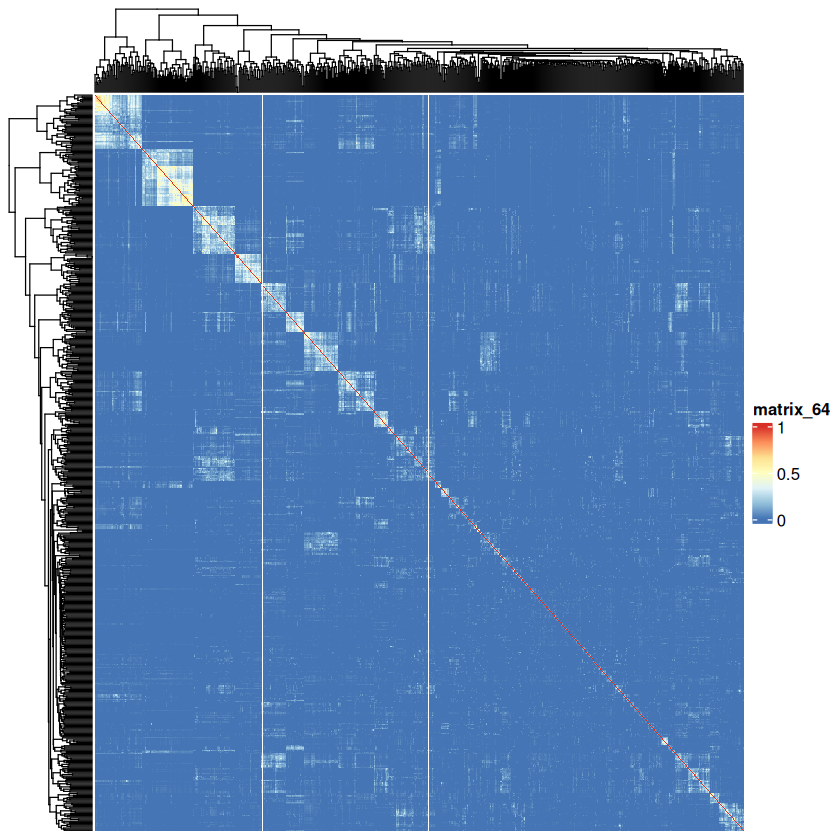

In [14]:
for (i in 1:5){
  all = unlist(modules.list, recursive = FALSE, use.names = TRUE)
  all = lapply(all, intersect, genes.use)
  sim = sapply(all, function(x){
    sapply(all, function(y){
      length(intersect(x,y))/length(union(x,y))
    })
  })
  keep = rownames(sim)[apply(sim, 1, function(x){
    # sum(x > 0.05) >= 5
    sum(x > 0.05) >= 2
  })]
  all = all[keep]
  modules.list = lapply(names(modules.list), function(x){
    li = modules.list[[x]]
    li[names(li)[paste(x,names(li),sep='.') %in% keep]]
  })
  names(modules.list) =  names(res_optima_L)
  ta = table(unlist(all))
  genes.use = names(ta)[ta > 1] 
  print(length(all))
}
# Filter the modules in the similarity matrix and keep those modules whose similarity coefficient with at least 5 other modules is greater than 0.05
pheatmap(sim,scale =T ,show_rownames= F, show_colnames = F)

In [15]:
sub = matrix(0, nrow = length(genes.use), ncol = length(genes.use))
  rownames(sub) = genes.use
  colnames(sub) = genes.use
  for (s in names(modules.list)){
    for (mod in modules.list[[s]]){
      mod = intersect(mod, genes.use)
      for (x in mod){
        for (y in mod){
          sub[x,y] = sub[x,y] + 1
        }
      }
    }
  }
  diag(sub) = 0
adj_keep = sub


v_min = 2 # from 3 to 2 

s_min = 1 # from 2 to 1 

adj = adj_keep 

adj[] = (adj >= v_min) 

for (i in 1:5){ 
    keep = names(which(rowSums(adj) >= s_min))
    adj = adj[keep,keep] 
    print(dim(adj))
}

[1] 2070 2070
[1] 2070 2070
[1] 2070 2070
[1] 2070 2070
[1] 2070 2070


In [16]:
g = graph_from_adjacency_matrix(adj, diag = FALSE, mode = 'undirected', weighted = TRUE)
modules = communities(cluster_infomap(g, nb.trials = 200))
names(modules) = paste0('m_', sapply(modules, '[', 1))


my_lengths <- sapply(modules, length)

modules <- subset(modules, my_lengths > 2)

 a <-lapply(modules, list)
modules <-lapply(a, unlist)

In [17]:
modules

$m_A4GNT
  [1] "A4GNT"        "ADH1C"        "ADIRF"        "AGR2"         "ALDH1B1"     
  [6] "ALDH3A1"      "ANXA2"        "ANXA5"        "APEX1"        "APRT"        
 [11] "AQP5"         "ARHGAP24"     "ASCL2"        "ATP5F1E"      "B3GNT7"      
 [16] "BANF1"        "BIRC3"        "BLVRB"        "BNIP3"        "BPIFB1"      
 [21] "BST2"         "BTF3"         "C16orf89"     "C19orf33"     "C1QBP"       
 [26] "C6orf58"      "CA9"          "CAPS"         "CCL25"        "CCND2"       
 [31] "CCT2"         "CD44"         "CD74"         "CD81"         "CD9"         
 [36] "CDC42EP5"     "CDCA7"        "CDK6"         "CHIA"         "CHP1"        
 [41] "CLDN10"       "CLDN2"        "CLIC3"        "CLTB"         "COA3"        
 [46] "COL11A2"      "COX5B"        "CPS1"         "CREB3L4"      "CRELD2"      
 [51] "CST3"         "CTSE"         "CXCL1"        "CXCL17"       "CXCL2"       
 [56] "CXCL3"        "CXCL8"        "CYSTM1"       "DCXR"         "DKK1"        
 [61] "DMBT1"        "DMKN"         "DYNLL1"       "EBPL"         "EEF1A1"      
 [66] "EEF1B2"       "EEF1D"        "EEF2"         "EIF3D"        "EIF3E"       
 [71] "EIF3L"        "ENC1"         "EPHB3"        "ETV5"         "FAM3D"       
 [76] "FBL"          "FCGRT"        "FKBP11"       "FMOD"         "FNDC3B"      
 [81] "FOLR1"        "FTL"          "FUT9"         "FXYD5"        "GADD45GIP1"  
 [86] "GAMT"         "GAPDH"        "GATM"         "GDF15"        "GOLM1"       
 [91] "GP2"          "GPER1"        "GPRC5A"       "GPT2"         "GPX2"        
 [96] "GSTA2"        "GSTM3"        "GSTP1"        "HLA.DMA"      "HLA.DPA1"    
[101] "HLA.DPB1"     "HLA.DQA2"     "HLA.DQB1"     "HLA.DRA"      "HLA.DRB1"    
[106] "HLA.DRB5"     "HMGCS2"       "HNRNPA1"      "HOMER2"       "HSP90AB1"    
[111] "ID1"          "ID3"          "IFI35"        "IGFBP2"       "IL33"        
[116] "IMPDH2"       "IRX2"         "IRX3"         "KCNE2"        "KCNE3"       
[121] "LCN2"         "LDHB"         "LEFTY1"       "LEPR"         "LGALS2"      
[126] "LINC02688"    "LIPF"         "LOC102723878" "LRRC17"       "LTF"         
[131] "LYZ"          "MARCKSL1"     "MBIP"         "MGST1"        "MIA"         
[136] "MLEC"         "MMP1"         "MMP7"         "MPC2"         "MRNIP"       
[141] "MRPL12"       "MT1E"         "MT1F"         "MT1G"         "MT1H"        
[146] "MT1X"         "MT2A"         "MTHFD2"       "MUC5B"        "MUC6"        
[151] "MYC"          "NACA"         "NBPF12"       "NDUFAF2"      "NDUFB7"      
[156] "NHP2"         "NIBAN1"       "NME1"         "NOP53"        "NPM1"        
[161] "NPM3"         "NR2F2"        "NUCB2"        "NUPR1"        "ODAM"        
[166] "OLFM4"        "ONECUT3"      "ORM1"         "ORM2"         "PABPC1"      
[171] "PAIP2B"       "PDIA2"        "PDIA6"        "PDK4"         "PDLIM1"      
[176] "PDZK1IP1"     "PFN1"         "PGA3"         "PGA4"         "PGA5"        
[181] "PGC"          "PHGDH"        "PHLDA1"       "PIGR"         "PIK3C2G"     
[186] "PLTP"         "PPP1R1B"      "PRAC1"        "PRDX1"        "PRDX4"       
[191] "PRPS2"        "PRR4"         "PRSS23"       "PSMB9"        "PTPRO"       
[196] "RACK1"        "RAMP1"        "RARRES2"      "REG1A"        "REG3A"       
[201] "RGMB"         "RGS5"         "RHOBTB1"      "RNF39"        "RPL10"       
[206] "RPL10A"       "RPL11"        "RPL12"        "RPL13"        "RPL13A"      
[211] "RPL14"        "RPL15"        "RPL17"        "RPL18"        "RPL18A"      
[216] "RPL19"        "RPL21"        "RPL22"        "RPL22L1"      "RPL23"       
[221] "RPL23A"       "RPL24"        "RPL26"        "RPL27"        "RPL27A"      
[226] "RPL28"        "RPL29"        "RPL3"         "RPL30"        "RPL31"       
[231] "RPL32"        "RPL34"        "RPL35"        "RPL35A"       "RPL36"       
[236] "RPL36A"       "RPL37"        "RPL37A"       "RPL38"        "RPL39"       
[241] "RPL4"         "RPL41"        "RPL5"         "RPL6"         "RPL7"        
[246] "RPL7A"        "

In [19]:
current_dir <- getwd()

dir_name <- basename(current_dir)

save.image(file = paste0(current_dir, "/", dir_name, ".RData"))


In [5]:
split_list <- readRDS('./01_split_list.rds')

In [6]:
AllTissue_merge <- merge(split_list[[1]],split_list[-1])

### recluster

In [ ]:
DefaultAssay(AllTissue_merge)
#RNA

AllTissue_merge <- NormalizeData(AllTissue_merge, verbose = FALSE)

#high-variable genes

#nfeatures = 3000
AllTissue_merge <- FindVariableFeatures(AllTissue_merge, nfeatures = 3000,
                                     assay = 'RNA',
                                     selection.method = "vst") 

In [ ]:
all.genes <- rownames(AllTissue_merge)

# Perform scaling on all genes to normalize the data
AllTissue_merge <- ScaleData(AllTissue_merge ,features = all.genes) 

AllTissue_merge <- ScaleData(AllTissue_merge, vars.to.regress = "MT.prop")  

AllTissue_merge <- RunPCA(AllTissue_merge,npcs = 30,features = VariableFeatures(object = AllTissue_merge)) 

In [ ]:
DefaultAssay(AllTissue_merge) <- 'RNA'

AllTissue_merge <- RunHarmony(AllTissue_merge,reduction = "pca",group.by.vars = "sample_name",reduction.save = "harmony") %>%
                    FindNeighbors(data,dims = 1:15, reduction = 'harmony') %>%
                    RunUMAP( dims = 1:15, reduction = 'harmony')

In [12]:
getwd()

[1] "/mnt/data00/minghui/project_NMF/02_NMFAllTissue"

In [13]:
saveRDS(AllTissue_merge ,'./03_AllTissue_merge.rds')

In [15]:
load('./02_NMFAllTissue.RData')

In [20]:
saveRDS(modules,'./01_modules.rds')